# 03 — Resource-Constrained Experiment
Dropped features: BS, Gestational Diabetes, Preexisting Diabetes, Mental Health
Pipeline: {Standard / None} → PCA(0.95) → SMOTE → 8 Models × 4 FE variants

In [17]:
import warnings; warnings.filterwarnings("ignore")
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline        import Pipeline as SkPipeline
from sklearn.preprocessing   import StandardScaler
from sklearn.decomposition   import PCA
from sklearn.linear_model    import LogisticRegression
from sklearn.tree            import DecisionTreeClassifier
from sklearn.ensemble        import (RandomForestClassifier, GradientBoostingClassifier,
                                     ExtraTreesClassifier)
from sklearn.svm             import SVC
from sklearn.metrics         import (make_scorer, accuracy_score, precision_score,
                                     recall_score, f1_score, classification_report)
from xgboost                 import XGBClassifier
from lightgbm                import LGBMClassifier
from imblearn.pipeline       import Pipeline as ImbPipeline
from imblearn.over_sampling  import SMOTE

RS       = 42
N_SPLITS = 10
SKF      = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RS)

SCORING = {
    "accuracy"   : make_scorer(accuracy_score),
    "precision_1": make_scorer(precision_score, pos_label=1, zero_division=0),
    "recall_1"   : make_scorer(recall_score,    pos_label=1, zero_division=0),
    "f1_1"       : make_scorer(f1_score,        pos_label=1, zero_division=0),
}

In [18]:
df = pd.read_csv('../data/processed/maternal_health_cleaned.csv')
print(df.shape)

(1168, 12)


## Feature Engineering

In [19]:
df["Is_Fever"] = (df["Body Temp"] > 99).astype(int)

binary_cols  = [col for col in df.select_dtypes(include=[np.number]).columns
                if df[col].dropna().isin([0, 1]).all()]
numeric_cols = [col for col in df.select_dtypes(include=[np.number]).columns
                if col not in binary_cols]

feature_cols = numeric_cols + binary_cols
X = df[feature_cols]
y = df["Risk Level"].map({"High": 1, "Low": 0})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RS, stratify=y
)
print(f"train: {X_train.shape[0]} | test: {X_test.shape[0]}")

train: 934 | test: 234


## Feature Engineering Variants (RC versions)
- **FE-A (RC)** — all features minus RC drops, keeps `Body Temp`  
- **FE-B (RC)** — also drops `Body Temp`  
- **FE-A-PP (RC)** — adds `Pulse Pressure` + `MAP`, keeps `Body Temp`  
- **FE-B-PP (RC)** — adds `Pulse Pressure` + `MAP`, drops `Body Temp`

In [ ]:
RC_DROP_COLS = ["BS", "Gestational Diabetes", "Preexisting Diabetes", "Mental Health"]

# fe-a rc: all features minus dropped columns
X_train_A_rc = X_train.drop(columns=[c for c in RC_DROP_COLS if c in X_train.columns]).copy()
X_test_A_rc  = X_test.drop(columns=[c for c in RC_DROP_COLS if c in X_test.columns]).copy()

# fe-b rc: also drop body temp
X_train_B_rc = X_train_A_rc.drop(columns=["Body Temp"], errors="ignore").copy()
X_test_B_rc  = X_test_A_rc.drop(columns=["Body Temp"],  errors="ignore").copy()

df_pp_rc = df.copy()
df_pp_rc = df_pp_rc.drop(columns=["Gestational Diabetes"], errors="ignore")
df_pp_rc["Pulse Pressure"] = df_pp_rc["Systolic BP"] - df_pp_rc["Diastolic"]
df_pp_rc["MAP"] = (df_pp_rc["Systolic BP"] + 2 * df_pp_rc["Diastolic"]) / 3

pp_rc_binary  = [c for c in df_pp_rc.select_dtypes(include=[np.number]).columns
                 if df_pp_rc[c].dropna().isin([0, 1]).all()]
pp_rc_numeric = [c for c in df_pp_rc.select_dtypes(include=[np.number]).columns
                 if c not in pp_rc_binary]
pp_rc_feat    = pp_rc_numeric + pp_rc_binary

X_pp_rc = df_pp_rc[pp_rc_feat]
X_train_pp_rc, X_test_pp_rc, _, _ = train_test_split(
    X_pp_rc, y, test_size=0.2, random_state=RS, stratify=y
)

# apply RC drops to PP variants
rc_drop_in_pp = [c for c in RC_DROP_COLS if c in X_train_pp_rc.columns]
X_train_A_PP_rc = X_train_pp_rc.drop(columns=rc_drop_in_pp, errors="ignore").copy()
X_test_A_PP_rc  = X_test_pp_rc.drop(columns=rc_drop_in_pp,  errors="ignore").copy()

X_train_B_PP_rc = X_train_A_PP_rc.drop(columns=["Body Temp"], errors="ignore").copy()
X_test_B_PP_rc  = X_test_A_PP_rc.drop(columns=["Body Temp"],  errors="ignore").copy()

FE_RC = {
    "FE-A (RC)":    (X_train_A_rc,    X_test_A_rc),
    "FE-B (RC)":    (X_train_B_rc,    X_test_B_rc),
    "FE-A-PP (RC)": (X_train_A_PP_rc, X_test_A_PP_rc),
    "FE-B-PP (RC)": (X_train_B_PP_rc, X_test_B_PP_rc),
}

for name, (tr, te) in FE_RC.items():
    print(f"{name}: train {tr.shape}, test {te.shape}  features: {tr.columns.tolist()}")

FE-A (RC): train (934, 8), test (234, 8)  features: ['Age', 'Systolic BP', 'Diastolic', 'Body Temp', 'BMI', 'Heart Rate', 'Previous Complications', 'Is_Fever']
FE-B (RC): train (934, 7), test (234, 7)  features: ['Age', 'Systolic BP', 'Diastolic', 'BMI', 'Heart Rate', 'Previous Complications', 'Is_Fever']
FE-A-PP (RC): train (934, 10), test (234, 10)  features: ['Age', 'Systolic BP', 'Diastolic', 'Body Temp', 'BMI', 'Heart Rate', 'Pulse Pressure', 'MAP', 'Previous Complications', 'Is_Fever']
FE-B-PP (RC): train (934, 9), test (234, 9)  features: ['Age', 'Systolic BP', 'Diastolic', 'BMI', 'Heart Rate', 'Pulse Pressure', 'MAP', 'Previous Complications', 'Is_Fever']


## Model Registry

In [21]:
BASE_MODELS = {
    "Logistic Regression": LogisticRegression(random_state=RS, max_iter=1000),
    "Decision Tree"      : DecisionTreeClassifier(random_state=RS),
    "Random Forest"      : RandomForestClassifier(random_state=RS, n_jobs=-1),
    "Gradient Boosting"  : GradientBoostingClassifier(random_state=RS),
    "XGBoost"            : XGBClassifier(random_state=RS, verbosity=0, eval_metric="logloss", n_jobs=-1),
    "LightGBM"           : LGBMClassifier(random_state=RS, verbose=-1, n_jobs=-1),
    "SVM"                : SVC(random_state=RS, probability=True),
    "Extra Trees"        : ExtraTreesClassifier(random_state=RS, n_jobs=-1),
}
print(f"{len(BASE_MODELS)} models registered: {list(BASE_MODELS.keys())}")

8 models registered: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting', 'XGBoost', 'LightGBM', 'SVM', 'Extra Trees']


## RC Pipeline Builder

In [ ]:
SCALING_OPTIONS = [("Standard", True), ("None", False)]

def build_rc_pipeline(model, scale=True):
    # pipeline: scaler - pca - smote - classifier
    # pca removes categorical structure so smote-nc is not applicable
    clf = copy.deepcopy(model)
    smote = SMOTE(random_state=RS)
    steps = []
    if scale:
        steps.append(("scaler", StandardScaler()))
    steps.extend([
        ("pca",       PCA(n_components=0.95, random_state=RS)),
        ("resampler", smote),
        ("clf",       clf),
    ])
    return ImbPipeline(steps)

## Resource-Constrained Leaderboard
4 FE variants × {Standard, None} × 8 Models — PCA(0.95) + SMOTE — Stratified 10-Fold CV

In [23]:
rc_records = []
total = len(FE_RC) * len(SCALING_OPTIONS) * len(BASE_MODELS)
done  = 0

for fe_name, (X_tr, X_te) in FE_RC.items():
    for scale_name, scale in SCALING_OPTIONS:
        # fit a temp pipeline to report pca components
        if scale:
            temp_data = StandardScaler().fit_transform(X_tr)
        else:
            temp_data = X_tr.values
        temp_pca = PCA(n_components=0.95, random_state=RS)
        temp_pca.fit(temp_data)
        print(f"\n{fe_name} | {scale_name}: {X_tr.shape[1]} features -> {temp_pca.n_components_} PCA components")

        for mdl_name, mdl in BASE_MODELS.items():
            done += 1
            try:
                pipe   = build_rc_pipeline(mdl, scale=scale)
                cv_res = cross_validate(pipe, X_tr, y_train, cv=SKF,
                                        scoring=SCORING, n_jobs=-1)
                row = {
                    "FE"         : fe_name,
                    "Scaling"    : scale_name,
                    "Model"      : mdl_name,
                    "Accuracy"   : round(cv_res["test_accuracy"].mean(),    4),
                    "Precision_1": round(cv_res["test_precision_1"].mean(), 4),
                    "Recall_1"   : round(cv_res["test_recall_1"].mean(),    4),
                    "F1_1"       : round(cv_res["test_f1_1"].mean(),        4),
                }
                rc_records.append(row)
                print(f"  [{done:>2}/{total}] {fe_name} | {scale_name:<8} | {mdl_name:<22} -> Recall_1={row['Recall_1']:.4f}")
            except Exception as exc:
                print(f"  SKIPPED {fe_name} | {scale_name} | {mdl_name}: {exc}")

rc_leaderboard = pd.DataFrame(rc_records).sort_values("Recall_1", ascending=False).reset_index(drop=True)
print("\n--- Resource-Constrained Leaderboard ---")
print("Top 10:")
display(rc_leaderboard.head(10))
print("\nBottom 10:")
display(rc_leaderboard.tail(10))


FE-A (RC) | Standard: 8 features -> 6 PCA components
  [ 1/64] FE-A (RC) | Standard | Logistic Regression    -> Recall_1=0.8303
  [ 2/64] FE-A (RC) | Standard | Decision Tree          -> Recall_1=0.8595
  [ 3/64] FE-A (RC) | Standard | Random Forest          -> Recall_1=0.9124
  [ 4/64] FE-A (RC) | Standard | Gradient Boosting      -> Recall_1=0.8966
  [ 5/64] FE-A (RC) | Standard | XGBoost                -> Recall_1=0.8966
  [ 6/64] FE-A (RC) | Standard | LightGBM               -> Recall_1=0.9070
  [ 7/64] FE-A (RC) | Standard | SVM                    -> Recall_1=0.9018
  [ 8/64] FE-A (RC) | Standard | Extra Trees            -> Recall_1=0.9046

FE-A (RC) | None: 8 features -> 4 PCA components
  [ 9/64] FE-A (RC) | None     | Logistic Regression    -> Recall_1=0.7666
  [10/64] FE-A (RC) | None     | Decision Tree          -> Recall_1=0.8038
  [11/64] FE-A (RC) | None     | Random Forest          -> Recall_1=0.8644
  [12/64] FE-A (RC) | None     | Gradient Boosting      -> Recall_1=0.8

,FE,Scaling,Model,Accuracy,Precision_1,Recall_1,F1_1
0,FE-A-PP (RC),Standard,Random Forest,0.9229,0.8971,0.9151,0.9053
1,FE-A (RC),Standard,Random Forest,0.9272,0.9094,0.9124,0.9098
2,FE-B (RC),Standard,LightGBM,0.9336,0.9264,0.9100,0.9172
3,FE-B (RC),Standard,Extra Trees,0.9390,0.9376,0.9100,0.9226
4,FE-B-PP (RC),Standard,LightGBM,0.9315,0.9200,0.9099,0.9146
5,FE-B (RC),Standard,Random Forest,0.9304,0.9201,0.9099,0.9134
6,FE-B (RC),Standard,XGBoost,0.9315,0.9216,0.9098,0.9145
7,FE-B-PP (RC),Standard,XGBoost,0.9272,0.9105,0.9098,0.9098
8,FE-A (RC),Standard,LightGBM,0.9261,0.9112,0.9070,0.9081
9,FE-A-PP (RC),Standard,Extra Trees,0.9293,0.9197,0.9047,0.9115



Bottom 10:


,FE,Scaling,Model,Accuracy,Precision_1,Recall_1,F1_1
54,FE-A (RC),None,SVM,0.8747,0.8694,0.8116,0.8385
55,FE-B (RC),None,SVM,0.8736,0.8690,0.8090,0.8369
56,FE-A (RC),None,Decision Tree,0.8395,0.8018,0.8038,0.8014
57,FE-B (RC),None,Decision Tree,0.8298,0.7976,0.7797,0.7853
58,FE-B-PP (RC),None,Logistic Regression,0.8149,0.7737,0.7666,0.7679
59,FE-A (RC),None,Logistic Regression,0.8159,0.7764,0.7666,0.7691
60,FE-A-PP (RC),None,Logistic Regression,0.8149,0.7737,0.7666,0.7679
61,FE-B (RC),None,Logistic Regression,0.8138,0.7736,0.7640,0.7665
62,FE-A-PP (RC),None,SVM,0.8554,0.8684,0.7561,0.8064
63,FE-B-PP (RC),None,SVM,0.8554,0.8684,0.7561,0.8064


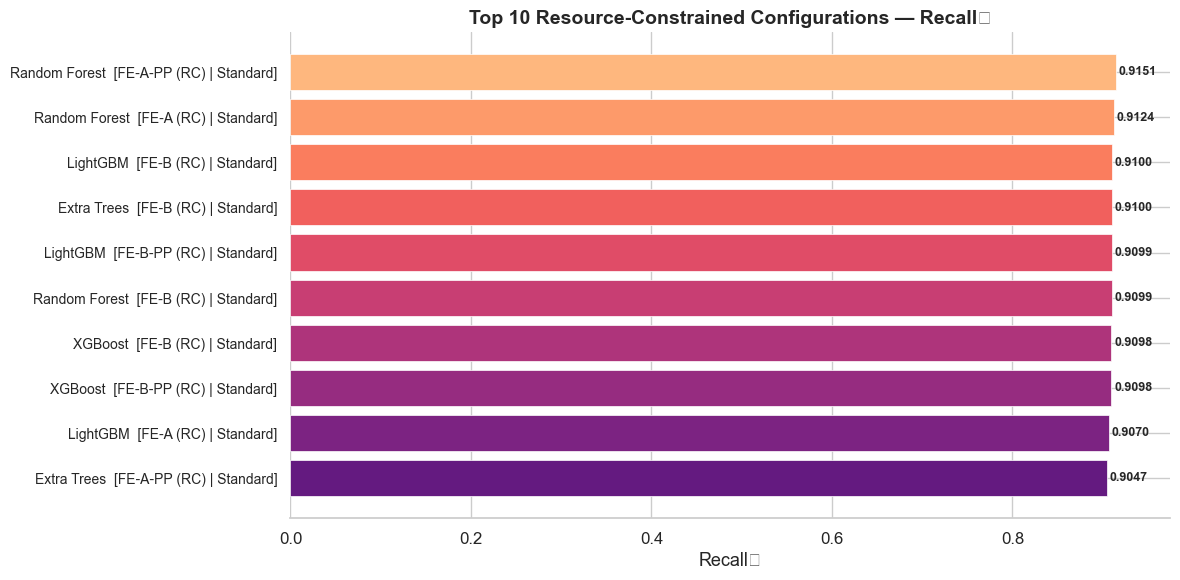

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import os
os.makedirs("../reports/figures", exist_ok=True)
sns.set_theme(style="whitegrid", font_scale=1.1)

fig, ax = plt.subplots(figsize=(12, 6))
top = rc_leaderboard.head(10).iloc[::-1]
labels = top.apply(
    lambda r: f"{r['Model']}  [{r['FE']} | {r['Scaling']}]", axis=1
)
colors = plt.cm.magma(np.linspace(0.3, 0.85, len(top)))
ax.barh(range(len(top)), top["Recall_1"], color=colors,
        edgecolor="white", linewidth=0.5)
ax.set_yticks(range(len(top)))
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlabel("Recall", fontsize=13)
ax.set_title("Top 10 Resource-Constrained Configurations — Recall\u2081",
             fontsize=14, fontweight="bold")
for i, v in enumerate(top["Recall_1"]):
    ax.text(v + 0.003, i, f"{v:.4f}", va="center", fontsize=9, fontweight="bold")
ax.set_xlim(right=top["Recall_1"].max() + 0.06)
sns.despine(left=True)
plt.tight_layout()
plt.savefig("../reports/figures/rc_top10_recall.png", dpi=150, bbox_inches="tight")
plt.show()

## Test Set Evaluation: Best RC Model

In [25]:
best_rc_row   = rc_leaderboard.iloc[0]
best_rc_fe    = best_rc_row["FE"]
best_rc_mdl   = best_rc_row["Model"]
best_rc_scale = (best_rc_row["Scaling"] == "Standard")

X_tr_rc_best, X_te_rc_best = FE_RC[best_rc_fe]

final_rc_pipe = build_rc_pipeline(BASE_MODELS[best_rc_mdl], scale=best_rc_scale)
final_rc_pipe.fit(X_tr_rc_best, y_train)
y_pred_rc = final_rc_pipe.predict(X_te_rc_best)

print(f"best RC model: {best_rc_mdl}  |  FE: {best_rc_fe}  |  scaling: {best_rc_row['Scaling']}")
print(classification_report(y_test, y_pred_rc, target_names=["Low Risk", "High Risk"]))

best RC model: Random Forest  |  FE: FE-A-PP (RC)  |  scaling: Standard
              precision    recall  f1-score   support

    Low Risk       0.95      0.90      0.93       139
   High Risk       0.86      0.94      0.90        95

    accuracy                           0.91       234
   macro avg       0.91      0.92      0.91       234
weighted avg       0.92      0.91      0.91       234



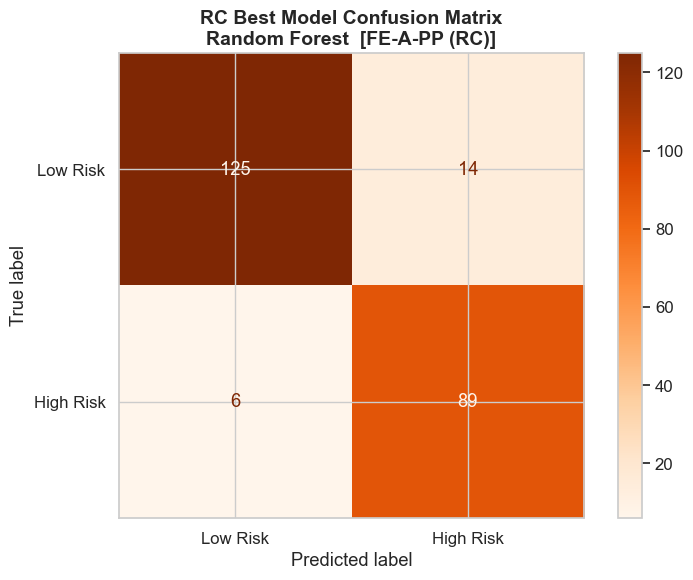


Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.95      0.90      0.93       139
   High Risk       0.86      0.94      0.90        95

    accuracy                           0.91       234
   macro avg       0.91      0.92      0.91       234
weighted avg       0.92      0.91      0.91       234



In [ ]:
# resource constrained best model confusion matrix
cm_rc = confusion_matrix(y_test, y_pred_rc)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(cm_rc, display_labels=["Low Risk", "High Risk"])
disp.plot(ax=ax, cmap="Oranges", values_format="d")
ax.set_title(f"RC Best Model Confusion Matrix\n{best_rc_mdl}  [{best_rc_fe}]",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/figures/rc_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rc, target_names=["Low Risk", "High Risk"]))